In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

df = pd.read_csv("data\\annotated_data.csv")
df

,Unnamed: 0,full_name,transactor_type
0,0,franklin county reagan coalition,Committee
1,1,nextgen climate action committee,Committee
2,2,zarwin baum good government pac,Committee
3,3,mid-atlantic laborers' political league,Committee
4,4,toll bros inc pac,Committee
...,...,...,...
518281,1048568,cindy olofson,Individual
518282,1048569,ryan olsen,Individual
518283,1048570,andrew orgill,Individual
518284,1048572,chris ortega,Individual


In [175]:
# # clean string columns
# for col in ['transactor_type', 'reported_state', 'party', 'full_name']:
#     df[col] = df[col].astype(str).str.strip().str.title()

# # replace filler or unknown values with NA
# filler_values = ['Na', 'N/A', 'None', 'Unknown', 'Nan']
# df.replace(filler_values, pd.NA, inplace=True)

# # drop rows with missing key fields
# df.dropna(subset=['full_name', 'transactor_type', 'reported_state', 'party'], inplace=True)

# # drop duplicate donors based on id or name
# df = df.drop_duplicates(subset=['full_name'])

def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Candidate' or input_label == 'Individual':
        return 1
    else:
        return 0

# encode transactor_type as numeric labels
df['label'] = np.vectorize(convert_bool)(df['transactor_type'])

# features and target for under-sampling
X = df[['full_name']]
y = df['label']

# apply random under-sampling to balance the classes
rus = RandomUnderSampler(random_state = 42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# merge resampled data with full original data
# df_resampled = pd.concat([X_resampled, y_resampled.rename("label")], axis = 1)

In [176]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X_resampled['full_name'])

In [177]:
# def convert_bool(input_label):
#     '''Converts to numerical encoding'''
#     if input_label == 'Committee':
#         return 1
#     else:
#         return 0
# y = np.vectorize(convert_bool)(df['transactor_type'])
# y = df_resampled['label']

(array([19069.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 19246.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

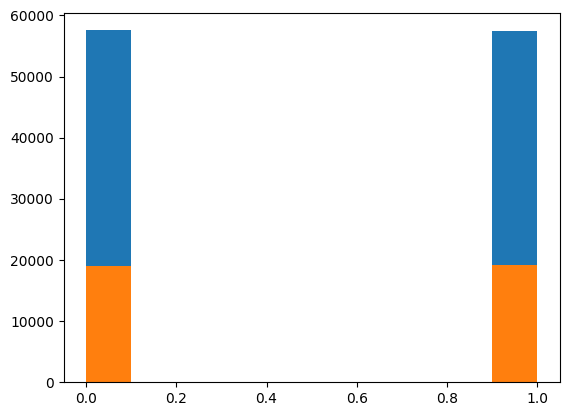

In [178]:
X_train, X_val, y_train, y_val = train_test_split(X, y_resampled, test_size = 0.25, random_state = 42)
plt.hist(y_train)
plt.hist(y_val)

In [179]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
predicted_y = rfc.predict(X_val)

In [190]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_val, predicted_y))

Accuracy: 88.86075949367088
Recall: 88.50670269146835
Precision: 89.22996333158721
f1_score: 88.86686143572621

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     19069
           1       0.89      0.89      0.89     19246

    accuracy                           0.89     38315
   macro avg       0.89      0.89      0.89     38315
weighted avg       0.89      0.89      0.89     38315



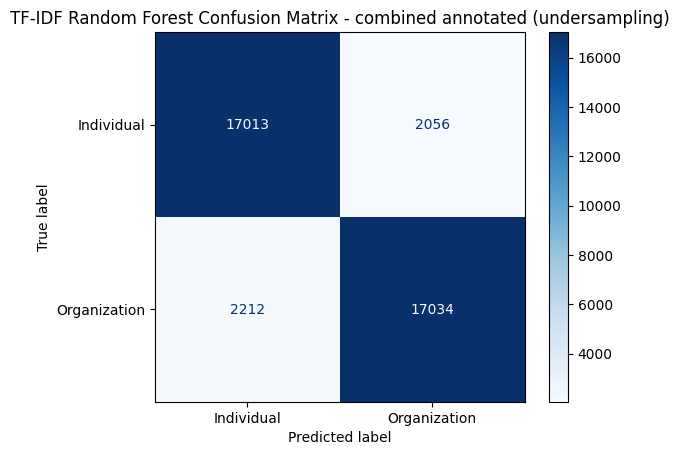

In [181]:
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("TF-IDF Random Forest Confusion Matrix - combined annotated (undersampling)")
plt.savefig('TF-IDF Random Forest Confusion Matrix - combined annotated (undersampling).png', transparent=True, bbox_inches = 'tight')
plt.show()

In [182]:
y_val

165237    1
355852    0
133935    0
72445     0
347253    1
         ..
402586    1
138432    0
228735    0
312170    1
226870    1
Name: label, Length: 38315, dtype: int64

In [183]:
misclassified = np.where(y_val != predicted_y)[0]
misclassified


array([   25,    62,    76, ..., 38293, 38307, 38309], shape=(4268,))

In [184]:
y_val_df = y_val.reset_index().copy()
y_val_df

,index,label
0,165237,1
1,355852,0
2,133935,0
3,72445,0
4,347253,1
...,...,...
38310,402586,1
38311,138432,0
38312,228735,0
38313,312170,1


In [185]:

inverse_names = vectorizer.inverse_transform(X_val)

inverse_names_clean = []
for i in misclassified:
	inverse_names_clean.append(" ".join(list(inverse_names[i])))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
	ctr+=1
	print(f"ctr: {ctr}")
	print(f"Index: {i}")
	print(f"Full Name: {inverse_names_clean[ctr]}")
	print(f"True Label: {y_val_df.iloc[i]['label']}, Predicted: {predicted_y[i]}")
	print("---")
# Committee = 0
# Individual = 1

Number of misclassified samples: 4268
ctr: 0
Index: 25
Full Name: roger zener
True Label: 0, Predicted: 1
---
ctr: 1
Index: 62
Full Name: ivory dontae
True Label: 1, Predicted: 0
---
ctr: 2
Index: 76
Full Name: safeway gasoline
True Label: 0, Predicted: 1
---
ctr: 3
Index: 80
Full Name: mcgee carson barney
True Label: 1, Predicted: 0
---
ctr: 4
Index: 81
Full Name: terran nogash
True Label: 1, Predicted: 0
---
ctr: 5
Index: 88
Full Name: may blevins
True Label: 0, Predicted: 1
---
ctr: 6
Index: 90
Full Name: williams annette
True Label: 0, Predicted: 1
---
ctr: 7
Index: 110
Full Name: white roger
True Label: 1, Predicted: 0
---
ctr: 8
Index: 120
Full Name: brooke sherrill
True Label: 0, Predicted: 1
---
ctr: 9
Index: 121
Full Name: craunover
True Label: 1, Predicted: 0
---
ctr: 10
Index: 130
Full Name: ossie motton
True Label: 1, Predicted: 0
---
ctr: 11
Index: 135
Full Name: lizbeth grob
True Label: 1, Predicted: 0
---
ctr: 12
Index: 150
Full Name: green
True Label: 0, Predicted: 1
--